<a href="https://colab.research.google.com/github/antonellagambarte/vision-por-computadoras-II/blob/main/01_optimized_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pipeline Optimizado para Clasificación de Enfermedades en Plantas

Este notebook mejora el pipeline anterior con las siguientes optimizaciones:

1. **Eliminación de imágenes duplicadas**: Detectamos y removemos imágenes duplicadas usando hashing perceptual para evitar sesgos en el entrenamiento
2. **Data Augmentation en clases subrepresentadas**: Aplicamos aumento de datos específicamente en las clases con menor representación para balancear el dataset
3. **Búsqueda de hiperparámetros con Optuna**: Optimizamos automáticamente learning rate, batch size, y arquitectura del clasificador

**Modelos a comparar:**
- MobileNetV2
- MobileNetV3

**Objetivo**: Maximizar recall y accuracy mientras mantenemos el modelo lo suficientemente ligero para deployment móvil.


In [2]:
test_execution = False


## Imports y Configuración Inicial


In [9]:
#!pip install optuna

In [10]:
import gdown
import zipfile
import os
import time
import copy
import hashlib
from pathlib import Path
from collections import Counter, defaultdict
import shutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
import cv2

from sklearn.metrics import (confusion_matrix, accuracy_score, recall_score,
                            f1_score, roc_curve, auc, precision_recall_curve,
                            average_precision_score)
from sklearn.preprocessing import LabelBinarizer

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import transforms, datasets, models
from torch.utils.data import DataLoader, Subset, WeightedRandomSampler
from torch.ao.quantization import get_default_qconfig_mapping, get_default_qat_qconfig_mapping
from torch.ao.quantization.quantize_fx import prepare_fx, convert_fx, prepare_qat_fx

import optuna
from optuna.trial import TrialState
import warnings

# Configuración de dispositivo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

# Para asegurar reproducibilidad
torch.manual_seed(42)
np.random.seed(42)

# Silenciar warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)


Usando dispositivo: cuda


## Carga del Dataset


In [11]:
url = "https://drive.google.com/uc?id=1EAe3-k6Mj6UBd3uEA3gtotnSxtIIEkri"
output = "archivo.zip"
destino = "datos_zip"

def zip_is_valid(path):
    if not os.path.isfile(path) or os.path.getsize(path) == 0:
        return False
    try:
        with zipfile.ZipFile(path, 'r') as z:
            return z.testzip() is None
    except Exception as e:
        print("Error:", e)
        return False

# Descargar solo si no existe o si el zip es inválido
if not zip_is_valid(output):
    print("Descargando dataset...")
    gdown.download(url, output, quiet=False, fuzzy=True)
else:
    print(f"'{output}' ya existe.")

os.makedirs(destino, exist_ok=True)
with zipfile.ZipFile(output, 'r') as zip_ref:
    zip_ref.extractall(destino)

print("Archivo extraído correctamente en:", destino)


Descargando dataset...


Downloading...
From (original): https://drive.google.com/uc?id=1EAe3-k6Mj6UBd3uEA3gtotnSxtIIEkri
From (redirected): https://drive.google.com/uc?id=1EAe3-k6Mj6UBd3uEA3gtotnSxtIIEkri&confirm=t&uuid=d3bc437a-5b92-4fe3-a4ab-866b480fed67
To: /content/archivo.zip
100%|██████████| 2.19G/2.19G [00:37<00:00, 59.1MB/s]


Archivo extraído correctamente en: datos_zip


## 1. Detección y Eliminación de Duplicados

Utilizamos hashing perceptual (pHash) para detectar imágenes duplicadas o casi idénticas.
Esto previene que el modelo memorice la misma imagen y mejora la generalización.


In [12]:
def compute_file_hash(image_path, algo="md5", chunk_size=8192):
    """
    Calcula un hash exacto del archivo de imagen.
    Esto detecta imágenes idénticas (bit a bit).
    """
    hash_func = hashlib.md5() if algo == "md5" else hashlib.sha256()

    try:
        with open(image_path, "rb") as f:
            while chunk := f.read(chunk_size):
                hash_func.update(chunk)
        return hash_func.hexdigest()
    except Exception as e:
        print(f"Error procesando {image_path}: {e}")
        return None

def find_duplicate_images(data_dir, algo="md5"):
    """
    Encuentra imágenes duplicadas exactas (mismo contenido).
    Retorna dict {hash: [paths]} donde paths > 1 son duplicados.
    """
    hash_dict = defaultdict(list)

    print("Calculando hashes exactos...")
    for root, dirs, files in os.walk(data_dir):
        for file in tqdm(files, desc=f"Procesando {os.path.basename(root)}"):
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                file_path = os.path.join(root, file)
                img_hash = compute_file_hash(file_path, algo)

                if img_hash:
                    hash_dict[img_hash].append(file_path)

    # Filtrar solo duplicados
    duplicates = {h: paths for h, paths in hash_dict.items() if len(paths) > 1}
    return duplicates


def remove_duplicates(data_dir, duplicates_dict):
    """
    Elimina imágenes duplicadas, manteniendo solo una copia de cada grupo.
    """
    removed_count = 0

    for img_hash, paths in duplicates_dict.items():
        # Mantener la primera imagen, eliminar el resto
        for path_to_remove in paths[1:]:
            try:
                os.remove(path_to_remove)
                removed_count += 1
            except Exception as e:
                print(f"Error eliminando {path_to_remove}: {e}")

    return removed_count


In [13]:
# Ejecutar detección y eliminación de duplicados
data_dir = "datos_zip/plantvillage dataset/color"

print("="*70)
print("PASO 1: DETECCIÓN Y ELIMINACIÓN DE DUPLICADOS")
print("="*70)

duplicates = find_duplicate_images(data_dir)

if duplicates:
    print(f"\n📊 Se encontraron {len(duplicates)} grupos de imágenes duplicadas")
    print(f"   Total de imágenes duplicadas: {sum(len(paths)-1 for paths in duplicates.values())}")

    # Mostrar algunos ejemplos
    print("\n📋 Primeros 5 grupos de duplicados:")
    for i, (img_hash, paths) in enumerate(list(duplicates.items())[:5]):
        print(f"  Grupo {i+1}: {len(paths)} copias")
        for path in paths[:3]:  # Mostrar max 3 paths
            print(f"    - {path}")

    # Eliminar duplicados
    print("\n🗑️ Eliminando duplicados...")
    removed = remove_duplicates(data_dir, duplicates)
    print(f"✅ Se eliminaron {removed} imágenes duplicadas")
else:
    print("✅ No se encontraron duplicados en el dataset")


PASO 1: DETECCIÓN Y ELIMINACIÓN DE DUPLICADOS
Calculando hashes exactos...


Procesando color: 0it [00:00, ?it/s]
Procesando Soybean___healthy: 100%|██████████| 5090/5090 [00:00<00:00, 16012.96it/s]
Procesando Cherry_(including_sour)___Powdery_mildew: 100%|██████████| 1052/1052 [00:00<00:00, 22394.49it/s]
Procesando Grape___Esca_(Black_Measles): 100%|██████████| 1383/1383 [00:00<00:00, 15971.28it/s]
Procesando Orange___Haunglongbing_(Citrus_greening): 100%|██████████| 5507/5507 [00:00<00:00, 21897.50it/s]
Procesando Corn_(maize)___Common_rust_: 100%|██████████| 1192/1192 [00:00<00:00, 20008.69it/s]
Procesando Tomato___Tomato_Yellow_Leaf_Curl_Virus: 100%|██████████| 5357/5357 [00:00<00:00, 20092.13it/s]
Procesando Strawberry___Leaf_scorch: 100%|██████████| 1109/1109 [00:00<00:00, 16298.63it/s]
Procesando Tomato___Spider_mites Two-spotted_spider_mite: 100%|██████████| 1676/1676 [00:00<00:00, 15450.50it/s]
Procesando Potato___Early_blight: 100%|██████████| 1000/1000 [00:00<00:00, 15850.95it/s]
Procesando Grape___Leaf_blight_(Isariopsis_Leaf_Spot): 100%|██████████|


📊 Se encontraron 21 grupos de imágenes duplicadas
   Total de imágenes duplicadas: 21

📋 Primeros 5 grupos de duplicados:
  Grupo 1: 2 copias
    - datos_zip/plantvillage dataset/color/Tomato___Late_blight/5688ea99-c949-41d0-bbab-9cbf0ffb8bcd___GHLB2 Leaf 8677.JPG
    - datos_zip/plantvillage dataset/color/Tomato___Late_blight/e20107e7-137f-400e-817f-5dc4c58e5d70___GHLB2 Leaf 8677.JPG
  Grupo 2: 2 copias
    - datos_zip/plantvillage dataset/color/Tomato___Late_blight/2c47b891-3c97-48f1-a2cc-5aa53d3a1148___GHLB2 Leaf 9011.JPG
    - datos_zip/plantvillage dataset/color/Tomato___Late_blight/1a69b38b-c4eb-42c4-9584-bcb14fb8db0c___GHLB2 Leaf 9011.JPG
  Grupo 3: 2 copias
    - datos_zip/plantvillage dataset/color/Tomato___Late_blight/861d8b00-57a4-46b0-b51a-09d102dbe119___GHLB_PS Leaf 24 Day 13.jpg
    - datos_zip/plantvillage dataset/color/Tomato___Late_blight/d82b634e-9a19-497b-b698-aaf100d622a1___GHLB_PS Leaf 24 Day 13.jpg
  Grupo 4: 2 copias
    - datos_zip/plantvillage dataset/color/To

## 2. Análisis de Distribución de Clases

Analizamos cuántas imágenes tiene cada clase para identificar desbalance.


PASO 2: ANÁLISIS DE DISTRIBUCIÓN DE CLASES

📊 Dataset Statistics:
   Total de clases: 38
   Total de imágenes: 54284
   Promedio por clase: 1428.5

📉 Top 10 clases con MENOS imágenes:
   Potato___healthy                                  :   152 imágenes (0.28%)
   Apple___Cedar_apple_rust                          :   275 imágenes (0.51%)
   Peach___healthy                                   :   360 imágenes (0.66%)
   Raspberry___healthy                               :   371 imágenes (0.68%)
   Tomato___Tomato_mosaic_virus                      :   373 imágenes (0.69%)
   Grape___healthy                                   :   423 imágenes (0.78%)
   Strawberry___healthy                              :   456 imágenes (0.84%)
   Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot:   513 imágenes (0.95%)
   Apple___Black_rot                                 :   621 imágenes (1.14%)
   Apple___Apple_scab                                :   630 imágenes (1.16%)

📈 Top 10 clases con MÁS imágenes:
 

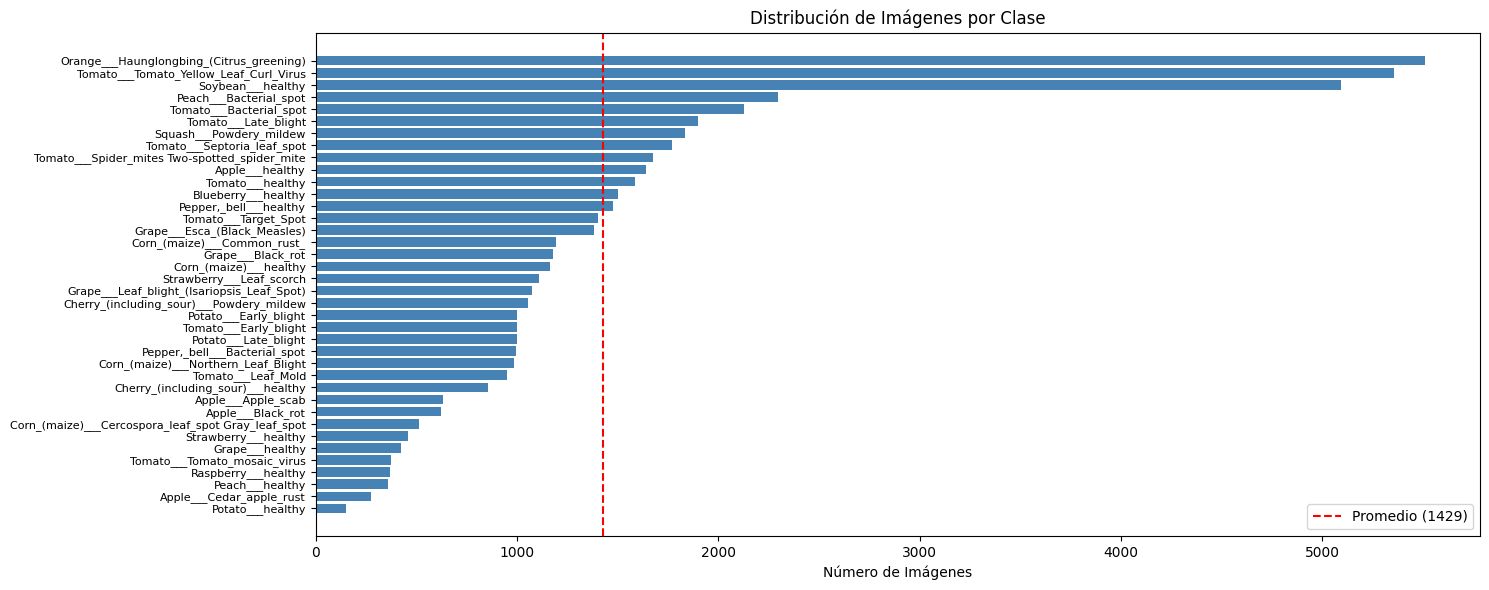


⚠️ Clases con representación baja (< 80% del promedio):
   20 clases requieren augmentation
   Potato___healthy                                  :   152 → necesita ~ 990 imágenes más
   Apple___Cedar_apple_rust                          :   275 → necesita ~ 867 imágenes más
   Peach___healthy                                   :   360 → necesita ~ 782 imágenes más
   Raspberry___healthy                               :   371 → necesita ~ 771 imágenes más
   Tomato___Tomato_mosaic_virus                      :   373 → necesita ~ 769 imágenes más
   Grape___healthy                                   :   423 → necesita ~ 719 imágenes más
   Strawberry___healthy                              :   456 → necesita ~ 686 imágenes más
   Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot:   513 → necesita ~ 629 imágenes más
   Apple___Black_rot                                 :   621 → necesita ~ 521 imágenes más
   Apple___Apple_scab                                :   630 → necesita ~ 512 imágenes m

In [14]:
def analyze_class_distribution(data_dir):
    """
    Analiza la distribución de imágenes por clase.
    """
    class_counts = {}

    for class_name in os.listdir(data_dir):
        class_path = os.path.join(data_dir, class_name)
        if os.path.isdir(class_path):
            img_files = [f for f in os.listdir(class_path)
                        if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            class_counts[class_name] = len(img_files)

    return class_counts

print("="*70)
print("PASO 2: ANÁLISIS DE DISTRIBUCIÓN DE CLASES")
print("="*70)

class_distribution = analyze_class_distribution(data_dir)
total_images = sum(class_distribution.values())
num_classes = len(class_distribution)

print(f"\n📊 Dataset Statistics:")
print(f"   Total de clases: {num_classes}")
print(f"   Total de imágenes: {total_images}")
print(f"   Promedio por clase: {total_images / num_classes:.1f}")

# Ordenar por cantidad de imágenes
sorted_classes = sorted(class_distribution.items(), key=lambda x: x[1])

print(f"\n📉 Top 10 clases con MENOS imágenes:")
for class_name, count in sorted_classes[:10]:
    print(f"   {class_name:50s}: {count:5d} imágenes ({count/total_images*100:.2f}%)")

print(f"\n📈 Top 10 clases con MÁS imágenes:")
for class_name, count in sorted_classes[-10:]:
    print(f"   {class_name:50s}: {count:5d} imágenes ({count/total_images*100:.2f}%)")

# Visualizar distribución
plt.figure(figsize=(15, 6))
classes_sorted = [c[0] for c in sorted_classes]
counts_sorted = [c[1] for c in sorted_classes]

plt.barh(range(len(classes_sorted)), counts_sorted, color='steelblue')
plt.yticks(range(len(classes_sorted)), classes_sorted, fontsize=8)
plt.xlabel('Número de Imágenes')
plt.title('Distribución de Imágenes por Clase')
plt.axvline(x=total_images/num_classes, color='red', linestyle='--',
            label=f'Promedio ({total_images/num_classes:.0f})')
plt.legend()
plt.tight_layout()
plt.show()

# Identificar clases con menos representación (< 80% del promedio)
threshold = 0.8 * (total_images / num_classes)
underrepresented_classes = {c: count for c, count in class_distribution.items()
                           if count < threshold}

print(f"\n⚠️ Clases con representación baja (< 80% del promedio):")
print(f"   {len(underrepresented_classes)} clases requieren augmentation")
for class_name, count in sorted(underrepresented_classes.items(), key=lambda x: x[1]):
    needed = int(threshold - count)
    print(f"   {class_name:50s}: {count:5d} → necesita ~{needed:4d} imágenes más")


## 3. Data Augmentation para Clases Desbalanceadas

Aplicamos augmentation selectivo solo a las clases con menor representación.
Esto balancea el dataset sin sobre-aumentar las clases ya bien representadas.


In [15]:
def create_augmentation_pipeline():
    """
    Crea un pipeline de augmentation. Se aplican: rotación de hasta 20 grados en amabas orientaciones;
    espejado de imagenes (horizontal y vertical); modificacion de brillo, contraste y saturación en un 20%;
    se mueve la imagen aleatoriamente en un 10% (horizontal y verticalmente); recorte aleatorio de entre un 80 y un 100%

    """
    return transforms.Compose([
        transforms.RandomRotation(20),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
        transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    ])

def augment_underrepresented_classes(data_dir, class_distribution, target_percentile=0.8):
    """
    Aumenta las clases con menos representación hasta alcanzar un umbral objetivo.

    Args:
        data_dir: Directorio raíz del dataset
        class_distribution: Dict con {clase: cantidad}
        target_percentile: Percentil objetivo (0.8 = 80% del promedio)
    """
    total_images = sum(class_distribution.values())
    num_classes = len(class_distribution)
    target_count = int(target_percentile * (total_images / num_classes))

    augmentation = create_augmentation_pipeline()
    total_generated = 0

    print("="*70)
    print("PASO 3: DATA AUGMENTATION SELECTIVO")
    print("="*70)
    print(f"Objetivo: ~{target_count} imágenes por clase")

    for class_name, current_count in tqdm(class_distribution.items(), desc="Procesando clases"):
        if current_count >= target_count:
            continue  # Clase ya tiene suficientes imágenes

        needed = target_count - current_count
        class_path = os.path.join(data_dir, class_name)

        # Obtener todas las imágenes de esta clase
        img_files = [f for f in os.listdir(class_path)
                    if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

        if not img_files:
            continue

        # Generar data augmentation
        generated = 0
        while generated < needed:
            # Seleccionar imagen origen aleatoria
            source_img_name = np.random.choice(img_files)
            source_img_path = os.path.join(class_path, source_img_name)

            try:
                # Cargar y aumentar
                img = Image.open(source_img_path).convert('RGB')
                augmented_img = augmentation(img)

                # Guardar con nombre único
                base_name = os.path.splitext(source_img_name)[0]
                aug_name = f"{base_name}_aug_{generated}.jpg"
                aug_path = os.path.join(class_path, aug_name)

                augmented_img.save(aug_path)
                generated += 1
                total_generated += 1

            except Exception as e:
                print(f"Error augmentando {source_img_path}: {e}")
                continue

        print(f"  ✓ {class_name:50s}: +{generated} imágenes ({current_count} → {current_count + generated})")

    print(f"\n✅ Data Augmentation completado: {total_generated} nuevas imágenes generadas")

    return total_generated


PASO 3: DATA AUGMENTATION SELECTIVO
Objetivo: ~1142 imágenes por clase


Procesando clases:   3%|▎         | 1/38 [00:04<02:51,  4.64s/it]

  ✓ Apple___Cedar_apple_rust                          : +867 imágenes (275 → 1142)


Procesando clases:   5%|▌         | 2/38 [00:05<01:25,  2.36s/it]

  ✓ Potato___Late_blight                              : +142 imágenes (1000 → 1142)


...

  ✓ Grape___Leaf_blight_(Isariopsis_Leaf_Spot)        : +66 imágenes (1076 → 1142)


Procesando clases:  89%|████████▉ | 34/38 [00:43<00:04,  1.18s/it]

  ✓ Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: +629 imágenes (513 → 1142)


Procesando clases: 100%|██████████| 38/38 [00:45<00:00,  1.21s/it]

  ✓ Apple___Apple_scab                                : +512 imágenes (630 → 1142)

✅ Data Augmentation completado: 8641 nuevas imágenes generadas

DISTRIBUCIÓN DESPUÉS DE AUGMENTATION

📊 Nuevas estadísticas:
   Total de imágenes: 62925 (antes: 54284, +8641)
   Promedio por clase: 1655.9


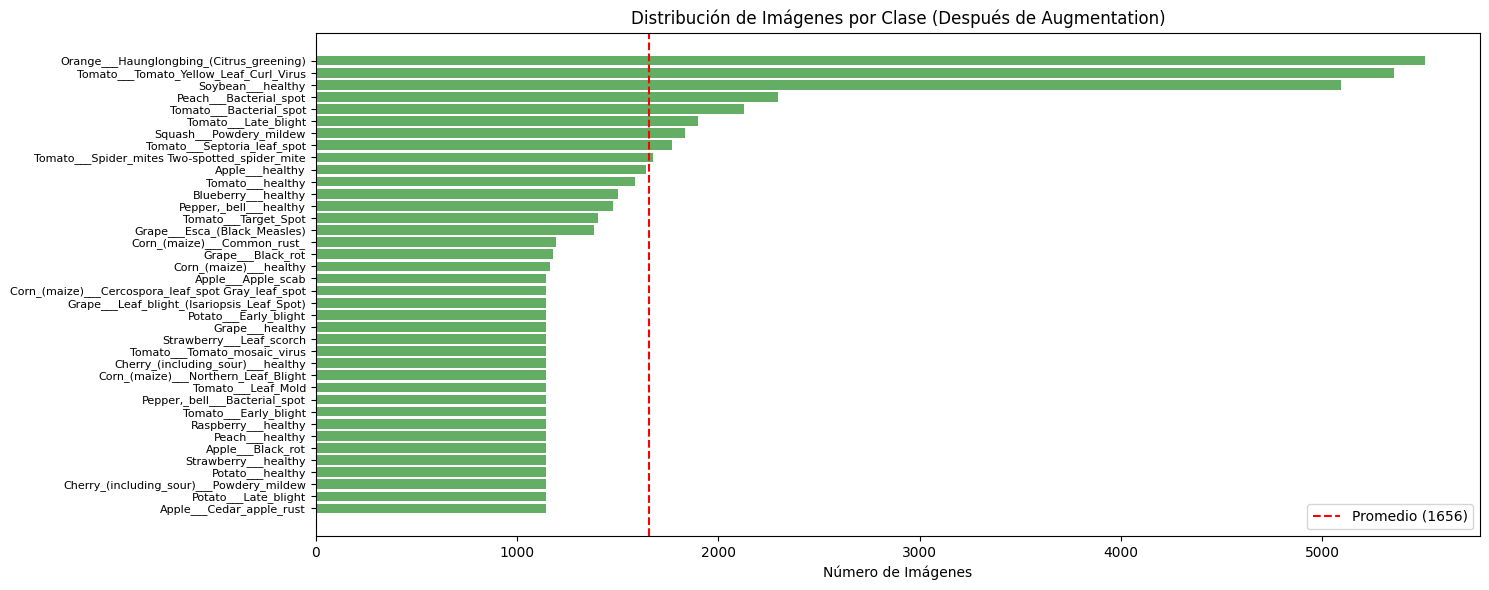

In [16]:
# Ejecutar data augmentation
generated_images = augment_underrepresented_classes(data_dir, class_distribution, target_percentile=0.8)

# Re-analizar distribución después del augmentation
print("\n" + "="*70)
print("DISTRIBUCIÓN DESPUÉS DE AUGMENTATION")
print("="*70)

new_distribution = analyze_class_distribution(data_dir)
new_total = sum(new_distribution.values())

print(f"\n📊 Nuevas estadísticas:")
print(f"   Total de imágenes: {new_total} (antes: {total_images}, +{new_total - total_images})")
print(f"   Promedio por clase: {new_total / num_classes:.1f}")

# Visualizar nueva distribución
plt.figure(figsize=(15, 6))
sorted_new = sorted(new_distribution.items(), key=lambda x: x[1])
classes_new = [c[0] for c in sorted_new]
counts_new = [c[1] for c in sorted_new]

plt.barh(range(len(classes_new)), counts_new, color='forestgreen', alpha=0.7)
plt.yticks(range(len(classes_new)), classes_new, fontsize=8)
plt.xlabel('Número de Imágenes')
plt.title('Distribución de Imágenes por Clase (Después de Augmentation)')
plt.axvline(x=new_total/num_classes, color='red', linestyle='--',
            label=f'Promedio ({new_total/num_classes:.0f})')
plt.legend()
plt.tight_layout()
plt.show()


## 4. Preparación de Datos y Transformaciones


In [17]:
# Transformaciones para train (con augmentation adicional ligero)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Transformaciones para val y test (sin augmentation)
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])


## 5. Partición Estratificada del Dataset


In [18]:
def stratified_split_indices(indices, labels, train_frac=0.8, val_frac=0.1, test_frac=0.1, rng=None):
    """
    Divide los índices de forma estratificada por clase.
    """
    if rng is None:
        rng = np.random.RandomState(0)

    train_idxs, val_idxs, test_idxs = [], [], []

    # Agrupar por clase
    class_to_idxs = {}
    for i in indices:
        class_to_idxs.setdefault(labels[i], []).append(i)

    # Dividir cada clase
    for cls, idxs in class_to_idxs.items():
        idxs = list(idxs)
        rng.shuffle(idxs)
        n = len(idxs)

        n_train = int(train_frac * n)
        n_val = int(val_frac * n)

        train_idxs.extend(idxs[:n_train])
        val_idxs.extend(idxs[n_train:n_train + n_val])
        test_idxs.extend(idxs[n_train + n_val:])

    return train_idxs, val_idxs, test_idxs

# Cargar dataset completo
full_dataset = datasets.ImageFolder(root=data_dir)
labels = [label for _, label in full_dataset.samples]
num_classes = len(full_dataset.classes)

rng = np.random.RandomState(42)

if test_execution:
    # Subset reducido para pruebas
    subset_indices = []
    reduction_factor = 0.1

    for class_idx in range(num_classes):
        class_indices = [i for i, (_, label) in enumerate(full_dataset.samples) if label == class_idx]
        n_samples = max(1, int(len(class_indices) * reduction_factor))
        chosen = rng.choice(class_indices, n_samples, replace=False).tolist()
        subset_indices.extend(chosen)

    rng.shuffle(subset_indices)
    train_indices, val_indices, test_indices = stratified_split_indices(
        subset_indices, labels, train_frac=0.8, val_frac=0.1, test_frac=0.1, rng=rng
    )

    train_dataset = Subset(datasets.ImageFolder(root=data_dir, transform=train_transform), train_indices)
    val_dataset = Subset(datasets.ImageFolder(root=data_dir, transform=val_transform), val_indices)
    test_dataset = Subset(datasets.ImageFolder(root=data_dir, transform=test_transform), test_indices)
else:
    # Dataset completo
    all_indices = list(range(len(full_dataset)))
    train_indices, val_indices, test_indices = stratified_split_indices(
        all_indices, labels, train_frac=0.8, val_frac=0.1, test_frac=0.1, rng=rng
    )

    train_dataset = Subset(full_dataset, train_indices)
    val_dataset = Subset(full_dataset, val_indices)
    test_dataset = Subset(full_dataset, test_indices)

    train_dataset.dataset.transform = train_transform
    val_dataset.dataset.transform = val_transform
    test_dataset.dataset.transform = test_transform

print(f"✅ Dataset preparado:")
print(f"   Clases: {num_classes}")
print(f"   Train: {len(train_dataset)}")
print(f"   Val: {len(val_dataset)}")
print(f"   Test: {len(test_dataset)}")


✅ Dataset preparado:
   Clases: 38
   Train: 50320
   Val: 6281
   Test: 6324


## 6. Funciones de Utilidad: Training y Evaluación


In [19]:
def train_model(model, dataloaders, criterion, optimizer, num_epochs=5, patience=3, device='cuda'):
    """
    Entrena un modelo con early stopping.
    """
    since = time.time()

    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': [],
        'train_recall': [], 'val_recall': [],
        'train_f1': [], 'val_f1': [],
        'train_auc_pr': [], 'val_auc_pr': []
    }

    model.to(device)
    best_metric = -np.inf
    counter = 0

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            all_labels = []
            all_preds = []
            all_probs = []

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    probs = torch.softmax(outputs, dim=1)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                all_labels.extend(labels.cpu().numpy())
                all_preds.extend(preds.cpu().numpy())
                all_probs.append(probs.detach().cpu().numpy())

            all_probs = np.vstack(all_probs)

            epoch_loss = running_loss / len(dataloaders[phase].dataset)
            epoch_acc = accuracy_score(all_labels, all_preds)
            epoch_recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
            epoch_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
            auc_pr = average_precision_score(all_labels, all_probs, average='macro')

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f} '
                  f'Recall: {epoch_recall:.4f} F1: {epoch_f1:.4f} AUC-PR: {auc_pr:.4f}')

            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc)
                history['train_recall'].append(epoch_recall)
                history['train_f1'].append(epoch_f1)
                history['train_auc_pr'].append(auc_pr)
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc)
                history['val_recall'].append(epoch_recall)
                history['val_f1'].append(epoch_f1)
                history['val_auc_pr'].append(auc_pr)

        # Early stopping
        epoch_metric = history['val_auc_pr'][-1]  # Usamos F1 como métrica principal

        if epoch_metric > best_metric:
            best_metric = epoch_metric
            counter = 0
            best_model_wts = copy.deepcopy(model.state_dict())
        else:
            counter += 1
            if counter >= patience:
                print(f"Early stopping en epoch {epoch+1}")
                break

    time_elapsed = time.time() - since
    print(f'\nEntrenamiento completado en {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Mejor AUC PR validation: {best_metric:.4f}')

    # Cargar los mejores pesos
    model.load_state_dict(best_model_wts)

    return model, history, time_elapsed


def evaluate_model(model, dataloader, device='cpu'):
    """
    Evalúa un modelo en un conjunto de datos.
    """
    model.to(device)
    model.eval()

    all_preds = []
    all_labels = []
    all_probs = []

    start_time = time.time()

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.append(probs.cpu().numpy())

    inference_time = time.time() - start_time
    all_probs = np.vstack(all_probs)

    accuracy = accuracy_score(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    auc_pr = average_precision_score(all_labels, all_probs, average='macro')

    return accuracy, recall, f1, auc_pr, inference_time


def get_model_size(model, model_name="model"):
    """
    Calcula el tamaño del modelo en disco.
    """
    torch.save(model.state_dict(), f"{model_name}.pth")
    size_mb = os.path.getsize(f"{model_name}.pth") / 1e6
    os.remove(f"{model_name}.pth")
    return size_mb


def plot_history(history, title="Training History"):
    """
    Grafica las métricas de entrenamiento.
    """
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    metrics = [('loss', 'Loss'), ('acc', 'Accuracy'), ('recall', 'Recall'),
               ('f1', 'F1 Score'), ('auc_pr', 'AUC-PR')]

    for idx, (metric, label) in enumerate(metrics):
        row = idx // 3
        col = idx % 3

        axes[row, col].plot(history[f'train_{metric}'], label='Train', marker='o')
        axes[row, col].plot(history[f'val_{metric}'], label='Validation', marker='s')
        axes[row, col].set_xlabel('Epoch')
        axes[row, col].set_ylabel(label)
        axes[row, col].set_title(f'{label} Over Time')
        axes[row, col].legend()
        axes[row, col].grid(True, alpha=0.3)

    # Ocultar el último subplot vacío
    axes[1, 2].axis('off')

    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()


## 7. Búsqueda de Hiperparámetros con Optuna

Utilizamos Optuna para encontrar los mejores hiperparámetros:
- Learning rate
- Batch size
- Arquitectura del clasificador (número de capas y neuronas)
- Optimizer (SGD vs Adam)
- Weight decay

**Nota:** Para acelerar la búsqueda, usamos solo el **30% del dataset** en los trials de Optuna.


#### Funciones

In [18]:
# Crear subsets del 30% para búsqueda de hiperparámetros (acelera el proceso)
print("="*70)
print("PREPARANDO SUBSETS PARA BÚSQUEDA DE HIPERPARÁMETROS")
print("="*70)

subset_fraction = 0.3  # Usar 30% del dataset

# Obtener labels de los datasets
if isinstance(train_dataset, Subset):
    train_labels = [train_dataset.dataset.targets[i] for i in train_dataset.indices]
    val_labels = [val_dataset.dataset.targets[i] for i in val_dataset.indices]
else:
    train_labels = [label for _, label in train_dataset.samples]
    val_labels = [label for _, label in val_dataset.samples]

# Crear subsets estratificados del 30%
def create_stratified_subset(dataset, labels, fraction, rng):
    """Crea un subset estratificado por clase."""
    class_to_idxs = {}
    for i, label in enumerate(labels):
        class_to_idxs.setdefault(label, []).append(i)

    subset_indices = []
    for class_label, indices in class_to_idxs.items():
        n_samples = max(1, int(len(indices) * fraction))
        chosen = rng.choice(indices, n_samples, replace=False).tolist()
        subset_indices.extend(chosen)

    rng.shuffle(subset_indices)
    return subset_indices

rng_optuna = np.random.RandomState(42)

# Crear índices para subsets
train_subset_indices = create_stratified_subset(train_dataset, train_labels, subset_fraction, rng_optuna)
val_subset_indices = create_stratified_subset(val_dataset, val_labels, subset_fraction, rng_optuna)

# Crear los subsets
if isinstance(train_dataset, Subset):
    # Si ya es un Subset, necesitamos mapear los índices
    train_optuna_indices = [train_dataset.indices[i] for i in train_subset_indices]
    val_optuna_indices = [val_dataset.indices[i] for i in val_subset_indices]

    train_dataset_optuna = Subset(train_dataset.dataset, train_optuna_indices)
    val_dataset_optuna = Subset(val_dataset.dataset, val_optuna_indices)
else:
    train_dataset_optuna = Subset(train_dataset, train_subset_indices)
    val_dataset_optuna = Subset(val_dataset, val_subset_indices)

print(f"\n✅ Subsets creados para Optuna:")
print(f"   Train subset: {len(train_dataset_optuna)} imágenes ({len(train_dataset_optuna)/len(train_dataset)*100:.1f}% del original)")
print(f"   Val subset: {len(val_dataset_optuna)} imágenes ({len(val_dataset_optuna)/len(val_dataset)*100:.1f}% del original)")
print("="*70)


PREPARANDO SUBSETS PARA BÚSQUEDA DE HIPERPARÁMETROS

✅ Subsets creados para Optuna:
   Train subset: 15070 imágenes (29.9% del original)
   Val subset: 1873 imágenes (29.8% del original)


In [19]:
def create_model_with_custom_classifier(model, num_classes, hidden_dim=512, num_layers=1, dropout=0.2):
    """
    Crea un modelo preentrenado con clasificador.
    """

    in_features = None
    for layer in model.classifier:
        if isinstance(layer, nn.Linear):
            in_features = layer.in_features
            break

    if in_features is None:
        raise ValueError("No se encontró capa Linear en model.classifier")

    # Congelar features
    for param in model.features.parameters():
        param.requires_grad = False

    # Crear capa de clasificador
    #in_features = model.classifier[1].in_features

    if num_layers == 1:
        model.classifier = nn.Sequential(
            nn.Linear(in_features, num_classes)
        )
    elif num_layers == 2:
        model.classifier = nn.Sequential(
            nn.Linear(in_features, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes)
        )
    else:  # 3 layers
        model.classifier = nn.Sequential(
            nn.Linear(in_features, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, num_classes)
        )

    return model


def objective(trial, modelo_preentrenado, train_dataset, val_dataset):
    """
    Función objetivo para Optuna.
    Usa un subset para acelerar la búsqueda.
    """
    print(f"Trial {trial.number} iniciado")

    # Hiperparámetros a optimizar
    lr = trial.suggest_float('lr', 1e-4, 1e-1, log=True)
    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128])
    hidden_dim = trial.suggest_categorical('hidden_dim', [256, 512, 1024])
    num_layers = trial.suggest_int('num_layers', 1, 3)
    dropout = trial.suggest_float('dropout', 0.1, 0.5)
    optimizer_name = trial.suggest_categorical('optimizer', ['SGD', 'Adam'])
    weight_decay = trial.suggest_float('weight_decay', 1e-6, 1e-3, log=True)

    # Crear dataloaders con el batch_size sugerido usando los SUBSETS
    trial_dataloaders = {
        'train': DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                          num_workers=2, prefetch_factor=2),
        'val': DataLoader(val_dataset, batch_size=batch_size, shuffle=False,
                        num_workers=2, prefetch_factor=2)
    }

    # Crear modelo
    model = create_model_with_custom_classifier(
        model=modelo_preentrenado,
        num_classes=num_classes,
        hidden_dim=hidden_dim,
        num_layers=num_layers,
        dropout=dropout
    )

    # Configurar optimizer
    criterion = nn.CrossEntropyLoss()

    if optimizer_name == 'SGD':
        optimizer = optim.SGD(model.classifier.parameters(), lr=lr,
                            momentum=0.9, weight_decay=weight_decay)
    else:
        optimizer = optim.Adam(model.classifier.parameters(), lr=lr,
                             weight_decay=weight_decay)

    # Entrenar por pocas épocas para evaluar rápido
    model.to(device)
    model.train()

    num_epochs_trial = 5  # Pocas épocas para cada trial

    for epoch in range(num_epochs_trial):
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            all_labels = []
            all_preds = []
            all_probs = []

            for inputs, labels in trial_dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    probs = torch.softmax(outputs, dim=1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                all_labels.extend(labels.cpu().numpy())
                all_preds.extend(preds.cpu().numpy())
                all_probs.append(probs.detach().cpu().numpy())

        all_probs = np.vstack(all_probs)

        # Calcular F1 en validación
        val_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
        val_auc_pr = average_precision_score(all_labels, all_probs, average='macro')

        # Reportar resultado intermedio
        #trial.report(val_f1, epoch)
        trial.report(val_auc_pr, epoch)

        # Podar trials que no sean prometedores
        if trial.should_prune():
            raise optuna.TrialPruned()

    #return val_f1  # Retornar F1 final de validación
    return val_auc_pr # Retornar AUC PR final de validación


In [20]:
def run_optuna_search(
    modelo_preentrenado,
    objective,
    train_dataset_optuna,
    val_dataset_optuna,
    subset_fraction=0.3,
    n_trials=10
):
    print("="*70)
    print(f"BÚSQUEDA DE HIPERPARÁMETROS CON OPTUNA ({subset_fraction*100}% del dataset)")
    print("="*70)

    # Crear estudio
    study = optuna.create_study(
        direction='maximize',  # Optimizar AUC PR
        pruner=optuna.pruners.MedianPruner(
            n_startup_trials=3,
            n_warmup_steps=2
        ),
        sampler=optuna.samplers.TPESampler(seed=42)
    )

    # Aviso
    print(f"\n🔍 Ejecutando {n_trials} trials de optimización...")
    print(f"   Usando {len(train_dataset_optuna)} imágenes de train "
          f"({subset_fraction*100:.0f}% del total)")
    print(f"   Usando {len(val_dataset_optuna)} imágenes de validación "
          f"({subset_fraction*100:.0f}% del total)")

    # 👉 Pasar el modelo mediante lambda
    study.optimize(
        lambda trial: objective(
            trial,
            modelo_preentrenado=modelo_preentrenado,
            train_dataset=train_dataset_optuna,
            val_dataset=val_dataset_optuna
        ),
        n_trials=n_trials,
        show_progress_bar=True
    )

    # Mostrar resultados
    print("\n" + "="*70)
    print("RESULTADOS DE LA OPTIMIZACIÓN")
    print("="*70)

    print(f"\n🏆 Mejor AUC PR: {study.best_value:.4f}")
    print(f"\n📋 Mejores hiperparámetros:")
    for key, value in study.best_params.items():
        print(f"   {key:15s}: {value}")

    # Importancia de parámetros
    try:
        fig = optuna.visualization.plot_param_importances(study)
        fig.show()
    except:
        print("\n⚠️ No se pudo generar gráfico de importancia (requiere plotly)")

    # Historial
    try:
        fig = optuna.visualization.plot_optimization_history(study)
        fig.show()
    except:
        print("⚠️ No se pudo generar gráfico de historia")

    print(f"\n✅ Hiperparámetros óptimos guardados")
    print(f"\n💡 Nota: Estos hiperparámetros fueron encontrados usando {subset_fraction*100:.0f}% del dataset.")

    return study.best_params, study


#### Búsqueda

In [ ]:
best_params_v2, study_v2 = run_optuna_search(
    modelo_preentrenado = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1),
    objective = objective,
    train_dataset_optuna = train_dataset_optuna,
    val_dataset_optuna = val_dataset_optuna,
    subset_fraction = 0.3,
    n_trials=30
)

``` [I 2025-12-02 01:44:09,347] A new study created in memory with name: no-name-2abbe17b-6d2b-4361-b43a-7fb011e804bd
======================================================================
BÚSQUEDA DE HIPERPARÁMETROS CON OPTUNA (30.0% del dataset)
======================================================================

🔍 Ejecutando 30 trials de optimización...
   Usando 15070 imágenes de train (30% del total)
   Usando 1873 imágenes de validación (30% del total)
Best trial: 2. Best value: 0.985645:  53%
 16/30 [25:21<22:11, 95.14s/it]
Trial 0 iniciado
[I 2025-12-02 01:46:03,985] Trial 0 finished with value: 0.933975806061715 and parameters: {'lr': 0.0013292918943162175, 'batch_size': 32, 'hidden_dim': 256, 'num_layers': 3, 'dropout': 0.34044600469728353, 'optimizer': 'SGD', 'weight_decay': 0.0008123245085588687}. Best is trial 0 with value: 0.933975806061715.
Trial 1 iniciado
[I 2025-12-02 01:47:55,927] Trial 1 finished with value: 0.9505214213761055 and parameters: {'lr': 0.03142880890840111, 'batch_size': 32, 'hidden_dim': 512, 'num_layers': 1, 'dropout': 0.34474115788895177, 'optimizer': 'Adam', 'weight_decay': 1.2562773503807034e-05}. Best is trial 1 with value: 0.9505214213761055.
Trial 2 iniciado
[I 2025-12-02 01:49:49,153] Trial 2 finished with value: 0.9856453586527143 and parameters: {'lr': 0.0023345864076016252, 'batch_size': 32, 'hidden_dim': 1024, 'num_layers': 1, 'dropout': 0.12602063719411183, 'optimizer': 'Adam', 'weight_decay': 0.0002661901888489054}. Best is trial 2 with value: 0.9856453586527143.
Trial 3 iniciado
[I 2025-12-02 01:50:56,685] Trial 3 pruned.
Trial 4 iniciado
[I 2025-12-02 01:52:48,805] Trial 4 finished with value: 0.9675518425013644 and parameters: {'lr': 0.004366473592979638, 'batch_size': 64, 'hidden_dim': 256, 'num_layers': 3, 'dropout': 0.1353970008207678, 'optimizer': 'SGD', 'weight_decay': 9.462175356461487e-06}. Best is trial 2 with value: 0.9856453586527143.
Trial 5 iniciado
[I 2025-12-02 01:53:57,133] Trial 5 pruned.
Trial 6 iniciado
[I 2025-12-02 01:55:05,619] Trial 6 pruned.
Trial 7 iniciado
[I 2025-12-02 01:57:00,010] Trial 7 finished with value: 0.9706227983833356 and parameters: {'lr': 0.0008569331925053991, 'batch_size': 64, 'hidden_dim': 256, 'num_layers': 3, 'dropout': 0.40431401944675904, 'optimizer': 'Adam', 'weight_decay': 3.0296104428212496e-05}. Best is trial 2 with value: 0.9856453586527143.
Trial 8 iniciado
[I 2025-12-02 01:58:31,065] Trial 8 pruned.
Trial 9 iniciado
[I 2025-12-02 02:00:24,782] Trial 9 pruned.

======================================================================
RESULTADOS DE LA OPTIMIZACIÓN
======================================================================

🏆 Mejor AUC PR: 0.9856

📋 Mejores hiperparámetros:
   lr             : 0.0023345864076016252
   batch_size     : 32
   hidden_dim     : 1024
   num_layers     : 1
   dropout        : 0.12602063719411183
   optimizer      : Adam
   weight_decay   : 0.0002661901888489054
```

In [20]:
best_params_v2 = {'lr': 0.0023345864076016252, 'batch_size': 32, 'hidden_dim': 1024, 'num_layers': 1, 'dropout': 0.12602063719411183, 'optimizer': 'Adam', 'weight_decay': 0.0002661901888489054}

In [ ]:
best_params_v3, study_v3 = run_optuna_search(
    modelo_preentrenado = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1),
    objective = objective,
    train_dataset_optuna = train_dataset_optuna,
    val_dataset_optuna = val_dataset_optuna,
    subset_fraction = 0.3,
    n_trials=10
)

```[I 2025-12-02 02:10:52,184] A new study created in memory with name: no-name-10af1f4d-6c67-4193-be1a-69ddec438149
======================================================================
BÚSQUEDA DE HIPERPARÁMETROS CON OPTUNA (30.0% del dataset)
======================================================================

🔍 Ejecutando 10 trials de optimización...
   Usando 15070 imágenes de train (30% del total)
   Usando 1873 imágenes de validación (30% del total)
Best trial: 2. Best value: 0.971229:  90%
 9/10 [12:48<01:18, 78.39s/it]
Trial 0 iniciado
[I 2025-12-02 02:12:45,751] Trial 0 finished with value: 0.7857115785227929 and parameters: {'lr': 0.0013292918943162175, 'batch_size': 32, 'hidden_dim': 256, 'num_layers': 3, 'dropout': 0.34044600469728353, 'optimizer': 'SGD', 'weight_decay': 0.0008123245085588687}. Best is trial 0 with value: 0.7857115785227929.
Trial 1 iniciado
[I 2025-12-02 02:14:39,191] Trial 1 finished with value: 0.9370863613622719 and parameters: {'lr': 0.03142880890840111, 'batch_size': 32, 'hidden_dim': 512, 'num_layers': 1, 'dropout': 0.34474115788895177, 'optimizer': 'Adam', 'weight_decay': 1.2562773503807034e-05}. Best is trial 1 with value: 0.9370863613622719.
Trial 2 iniciado
[I 2025-12-02 02:16:32,498] Trial 2 finished with value: 0.9712290215792896 and parameters: {'lr': 0.0023345864076016252, 'batch_size': 32, 'hidden_dim': 1024, 'num_layers': 1, 'dropout': 0.12602063719411183, 'optimizer': 'Adam', 'weight_decay': 0.0002661901888489054}. Best is trial 2 with value: 0.9712290215792896.
Trial 3 iniciado
[I 2025-12-02 02:17:39,926] Trial 3 pruned.
Trial 4 iniciado
[I 2025-12-02 02:18:46,692] Trial 4 pruned.
Trial 5 iniciado
[I 2025-12-02 02:19:53,813] Trial 5 pruned.
Trial 6 iniciado
[I 2025-12-02 02:21:02,404] Trial 6 pruned.
Trial 7 iniciado
[I 2025-12-02 02:22:10,536] Trial 7 pruned.
Trial 8 iniciado
[I 2025-12-02 02:23:40,378] Trial 8 pruned.
Trial 9 iniciado
[I 2025-12-02 02:24:47,341] Trial 9 pruned.

======================================================================
RESULTADOS DE LA OPTIMIZACIÓN
======================================================================

🏆 Mejor AUC PR: 0.9712

📋 Mejores hiperparámetros:
   lr             : 0.0023345864076016252
   batch_size     : 32
   hidden_dim     : 1024
   num_layers     : 1
   dropout        : 0.12602063719411183
   optimizer      : Adam
   weight_decay   : 0.0002661901888489054
   ```

In [21]:
best_params_v3 = {'lr': 0.0023345864076016252,
 'batch_size': 32,
 'hidden_dim': 1024,
 'num_layers': 1,
 'dropout': 0.12602063719411183,
 'optimizer': 'Adam',
 'weight_decay': 0.0002661901888489054}

## Entrenamientos con hoperparámetros óptimos

### 8.1 Modelo 1: MobileNetV2 Optimizado


In [27]:
# Crear dataloaders con el mejor batch_size encontrado por Optuna
# IMPORTANTE: Usamos los datasets COMPLETOS (train_dataset, val_dataset, test_dataset)
# NO los subsets del 30% que usamos para la búsqueda
optimal_batch_size = best_params_v2['batch_size']

dataloaders = {
    'train': DataLoader(train_dataset, batch_size=optimal_batch_size, shuffle=True,
                       num_workers=2, prefetch_factor=2),
    'val': DataLoader(val_dataset, batch_size=optimal_batch_size, shuffle=False,
                     num_workers=2, prefetch_factor=2),
    'test': DataLoader(test_dataset, batch_size=optimal_batch_size, shuffle=False,
                      num_workers=2, prefetch_factor=2)
}

print(f"✅ Dataloaders creados con batch_size={optimal_batch_size}")
print(f"   Train: {len(train_dataset)} imágenes (100% del dataset)")
print(f"   Val: {len(val_dataset)} imágenes (100% del dataset)")
print(f"   Test: {len(test_dataset)} imágenes (100% del dataset)")


✅ Dataloaders creados con batch_size=32
   Train: 50320 imágenes (100% del dataset)
   Val: 6281 imágenes (100% del dataset)
   Test: 6324 imágenes (100% del dataset)


ENTRENANDO MODELO 1: MobileNetV2 Optimizado
Epoch 1/30
----------
train Loss: 0.3155 Acc: 0.9097 Recall: 0.8937 F1: 0.8964 AUC-PR: 0.9458
val Loss: 0.1714 Acc: 0.9417 Recall: 0.9323 F1: 0.9337 AUC-PR: 0.9864
Epoch 2/30
----------
train Loss: 0.1731 Acc: 0.9438 Recall: 0.9342 F1: 0.9344 AUC-PR: 0.9742
val Loss: 0.2158 Acc: 0.9384 Recall: 0.9228 F1: 0.9215 AUC-PR: 0.9856
Epoch 3/30
----------
train Loss: 0.1481 Acc: 0.9524 Recall: 0.9441 F1: 0.9443 AUC-PR: 0.9801
val Loss: 0.1280 Acc: 0.9594 Recall: 0.9526 F1: 0.9510 AUC-PR: 0.9893
Epoch 4/30
----------
train Loss: 0.1459 Acc: 0.9531 Recall: 0.9453 F1: 0.9456 AUC-PR: 0.9809
val Loss: 0.1458 Acc: 0.9575 Recall: 0.9475 F1: 0.9491 AUC-PR: 0.9877
Epoch 5/30
----------
train Loss: 0.1447 Acc: 0.9542 Recall: 0.9462 F1: 0.9462 AUC-PR: 0.9819
val Loss: 0.1066 Acc: 0.9656 Recall: 0.9599 F1: 0.9598 AUC-PR: 0.9910
Epoch 6/30
----------
train Loss: 0.1400 Acc: 0.9554 Recall: 0.9476 F1: 0.9480 AUC-PR: 0.9832
val Loss: 0.1279 Acc: 0.9584 Recall: 0.952

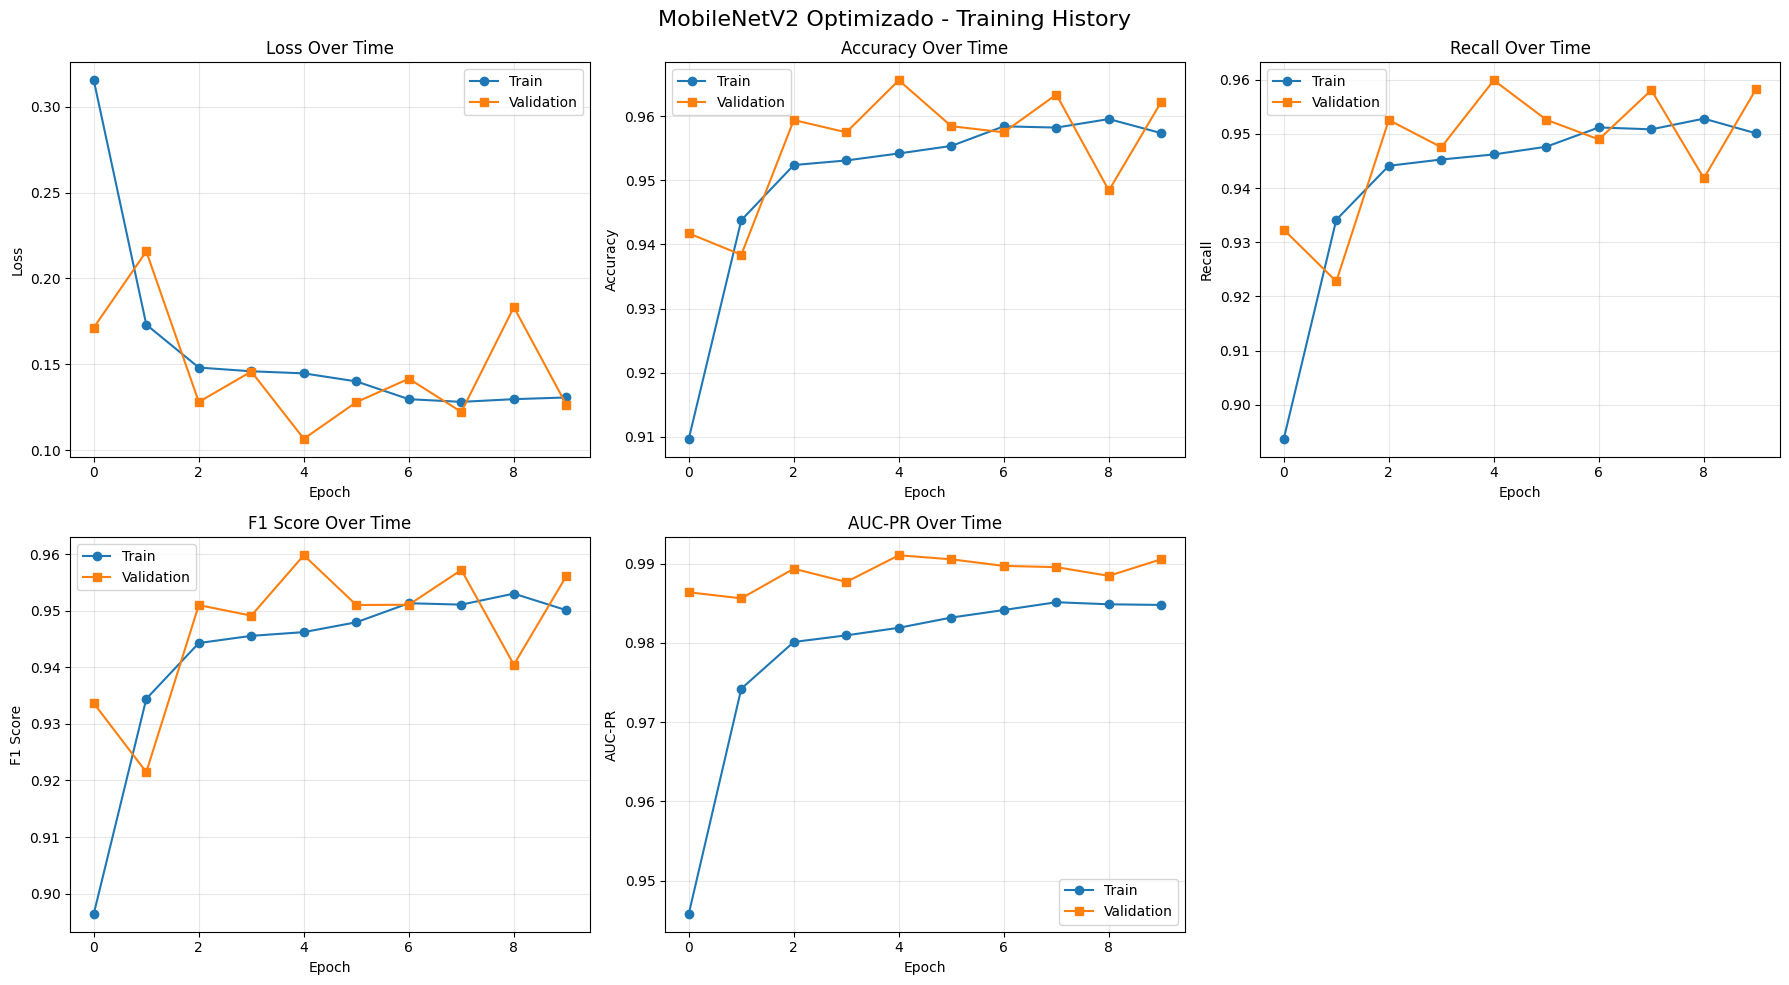

In [28]:
print("="*70)
print("ENTRENANDO MODELO 1: MobileNetV2 Optimizado")
print("="*70)

# Crear modelo con mejores hiperparámetros
model_v2_opt = create_model_with_custom_classifier(
    model=models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1),
    num_classes=num_classes,
    hidden_dim=best_params_v2['hidden_dim'],
    num_layers=best_params_v2['num_layers'],
    dropout=best_params_v2['dropout']
)

# Configurar optimizer y criterion
criterion = nn.CrossEntropyLoss()

if best_params_v2['optimizer'] == 'SGD':
    optimizer_v2 = optim.SGD(
        model_v2_opt.classifier.parameters(),
        lr=best_params_v2['lr'],
        momentum=0.9,
        weight_decay=best_params_v2['weight_decay']
    )
else:
    optimizer_v2 = optim.Adam(
        model_v2_opt.classifier.parameters(),
        lr=best_params_v2['lr'],
        weight_decay=best_params_v2['weight_decay']
    )

# Entrenar
num_epochs = 30
model_v2_opt, hist_v2, time_v2 = train_model(
    model_v2_opt,
    dataloaders,
    criterion,
    optimizer_v2,
    num_epochs=num_epochs,
    patience=5,
    device=device
)

# Visualizar resultados
plot_history(hist_v2, title="MobileNetV2 Optimizado - Training History")


### 8.2 Modelo 2: MobileNetV3 Small



ENTRENANDO MODELO 2: MobileNetV3 Small
Epoch 1/30
----------
train Loss: 0.4754 Acc: 0.8817 Recall: 0.8598 F1: 0.8667 AUC-PR: 0.9202
val Loss: 0.2132 Acc: 0.9389 Recall: 0.9258 F1: 0.9265 AUC-PR: 0.9748
Epoch 2/30
----------
train Loss: 0.2126 Acc: 0.9404 Recall: 0.9303 F1: 0.9308 AUC-PR: 0.9710
val Loss: 0.1808 Acc: 0.9460 Recall: 0.9321 F1: 0.9340 AUC-PR: 0.9810
Epoch 3/30
----------
train Loss: 0.1815 Acc: 0.9487 Recall: 0.9399 F1: 0.9405 AUC-PR: 0.9768
val Loss: 0.1698 Acc: 0.9527 Recall: 0.9434 F1: 0.9432 AUC-PR: 0.9826
Epoch 4/30
----------
train Loss: 0.1684 Acc: 0.9521 Recall: 0.9438 F1: 0.9442 AUC-PR: 0.9795
val Loss: 0.1424 Acc: 0.9588 Recall: 0.9516 F1: 0.9509 AUC-PR: 0.9853
Epoch 5/30
----------
train Loss: 0.1622 Acc: 0.9536 Recall: 0.9457 F1: 0.9463 AUC-PR: 0.9803
val Loss: 0.1470 Acc: 0.9551 Recall: 0.9464 F1: 0.9454 AUC-PR: 0.9847
Epoch 6/30
----------
train Loss: 0.1577 Acc: 0.9542 Recall: 0.9466 F1: 0.9469 AUC-PR: 0.9814
val Loss: 0.1498 Acc: 0.9534 Recall: 0.9449 F1

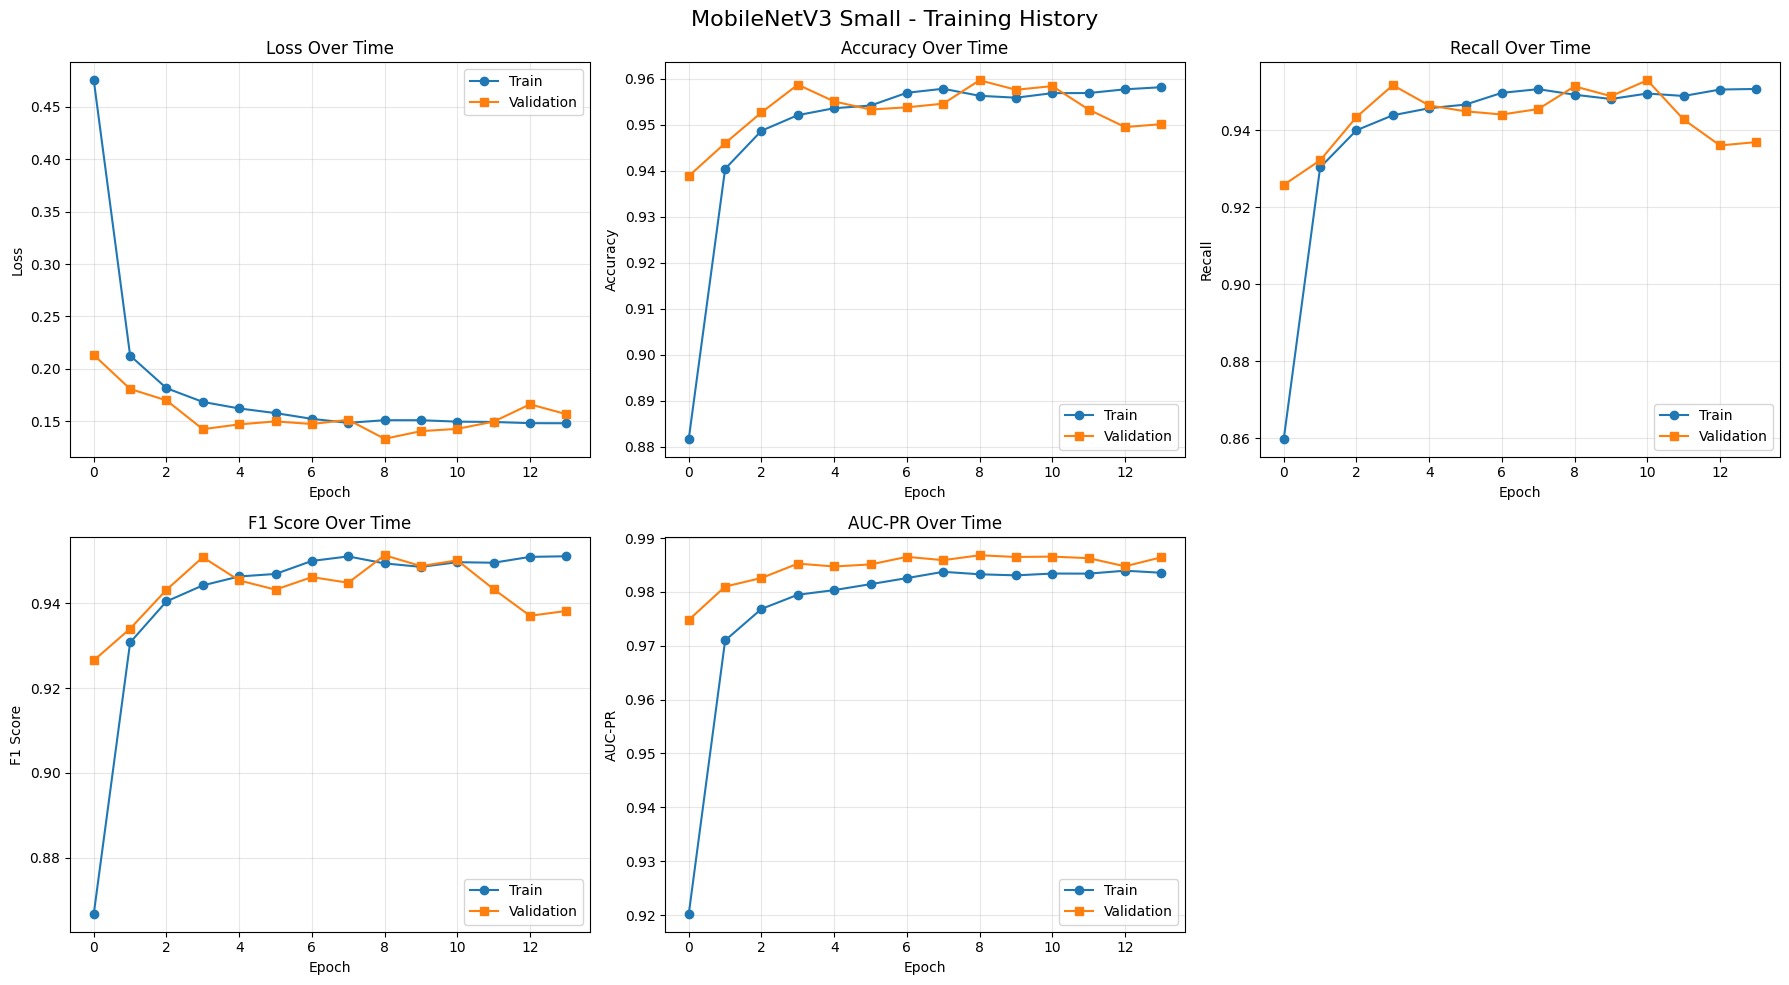

In [29]:
print("\n" + "="*70)
print("ENTRENANDO MODELO 2: MobileNetV3 Small")
print("="*70)

# Crear modelo con mejores hiperparámetros
model_v3_opt = create_model_with_custom_classifier(
    model=models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1),
    num_classes=num_classes,
    hidden_dim=best_params_v3['hidden_dim'],
    num_layers=best_params_v3['num_layers'],
    dropout=best_params_v3['dropout']
)

# Configurar optimizer y criterion
criterion = nn.CrossEntropyLoss()

if best_params_v3['optimizer'] == 'SGD':
    optimizer_v3 = optim.SGD(
        model_v3_opt.classifier.parameters(),
        lr=best_params_v3['lr'],
        momentum=0.9,
        weight_decay=best_params_v3['weight_decay']
    )
else:
    optimizer_v3 = optim.Adam(
        model_v3_opt.classifier.parameters(),
        lr=best_params_v2['lr'],
        weight_decay=best_params_v3['weight_decay']
    )

# Entrenar
num_epochs = 30
model_v3_opt, hist_v3, time_v3 = train_model(
    model_v3_opt,
    dataloaders,
    criterion,
    optimizer_v3,
    num_epochs=num_epochs,
    patience=5,
    device=device
)

# Visualizar resultados
plot_history(hist_v3, title="MobileNetV3 Small - Training History")


## 9. Evaluación y Comparación de Modelos


In [30]:
print("="*70)
print("EVALUACIÓN DE MODELOS EN TEST SET")
print("="*70)

# Evaluar todos los modelos en CPU para comparación justa
print("\nEvaluando MobileNetV2...")
acc_v2, recall_v2, f1_v2, auc_pr_v2, inf_time_v2 = evaluate_model(model_v2_opt, dataloaders['test'], 'cpu')
size_v2 = get_model_size(model_v2_opt, "v2_opt_temp")

print("\nEvaluando MobileNetV3...")
acc_v3, recall_v3, f1_v3, auc_pr_v3, inf_time_v3 = evaluate_model(model_v3_opt, dataloaders['test'], 'cpu')
size_v3 = get_model_size(model_v3_opt, "v3_temp")

# Crear tabla de resultados
results = {
    'MobileNetV2': {
        'Accuracy': acc_v2,
        'Recall': recall_v2,
        'F1 Score': f1_v2,
        'AUC-PR': auc_pr_v2,
        'Size (MB)': size_v2,
        'Inference Time (s)': inf_time_v2
    },
    'MobileNetV3': {
        'Accuracy': acc_v3,
        'Recall': recall_v3,
        'F1 Score': f1_v3,
        'AUC-PR': auc_pr_v3,
        'Size (MB)': size_v3,
        'Inference Time (s)': inf_time_v3
    }
}

df_results = pd.DataFrame(results).T

print("\n" + "="*70)
print("RESUMEN DE RESULTADOS")
print("="*70)
print(df_results.to_string())
print("="*70)


EVALUACIÓN DE MODELOS EN TEST SET

Evaluando MobileNetV2...

Evaluando MobileNetV3...

RESUMEN DE RESULTADOS
             Accuracy    Recall  F1 Score    AUC-PR  Size (MB)  Inference Time (s)
MobileNetV2  0.966319  0.960081  0.960391  0.991344   9.331723           96.735498
MobileNetV3  0.959677  0.951491  0.951924  0.986627   3.924955           14.702061


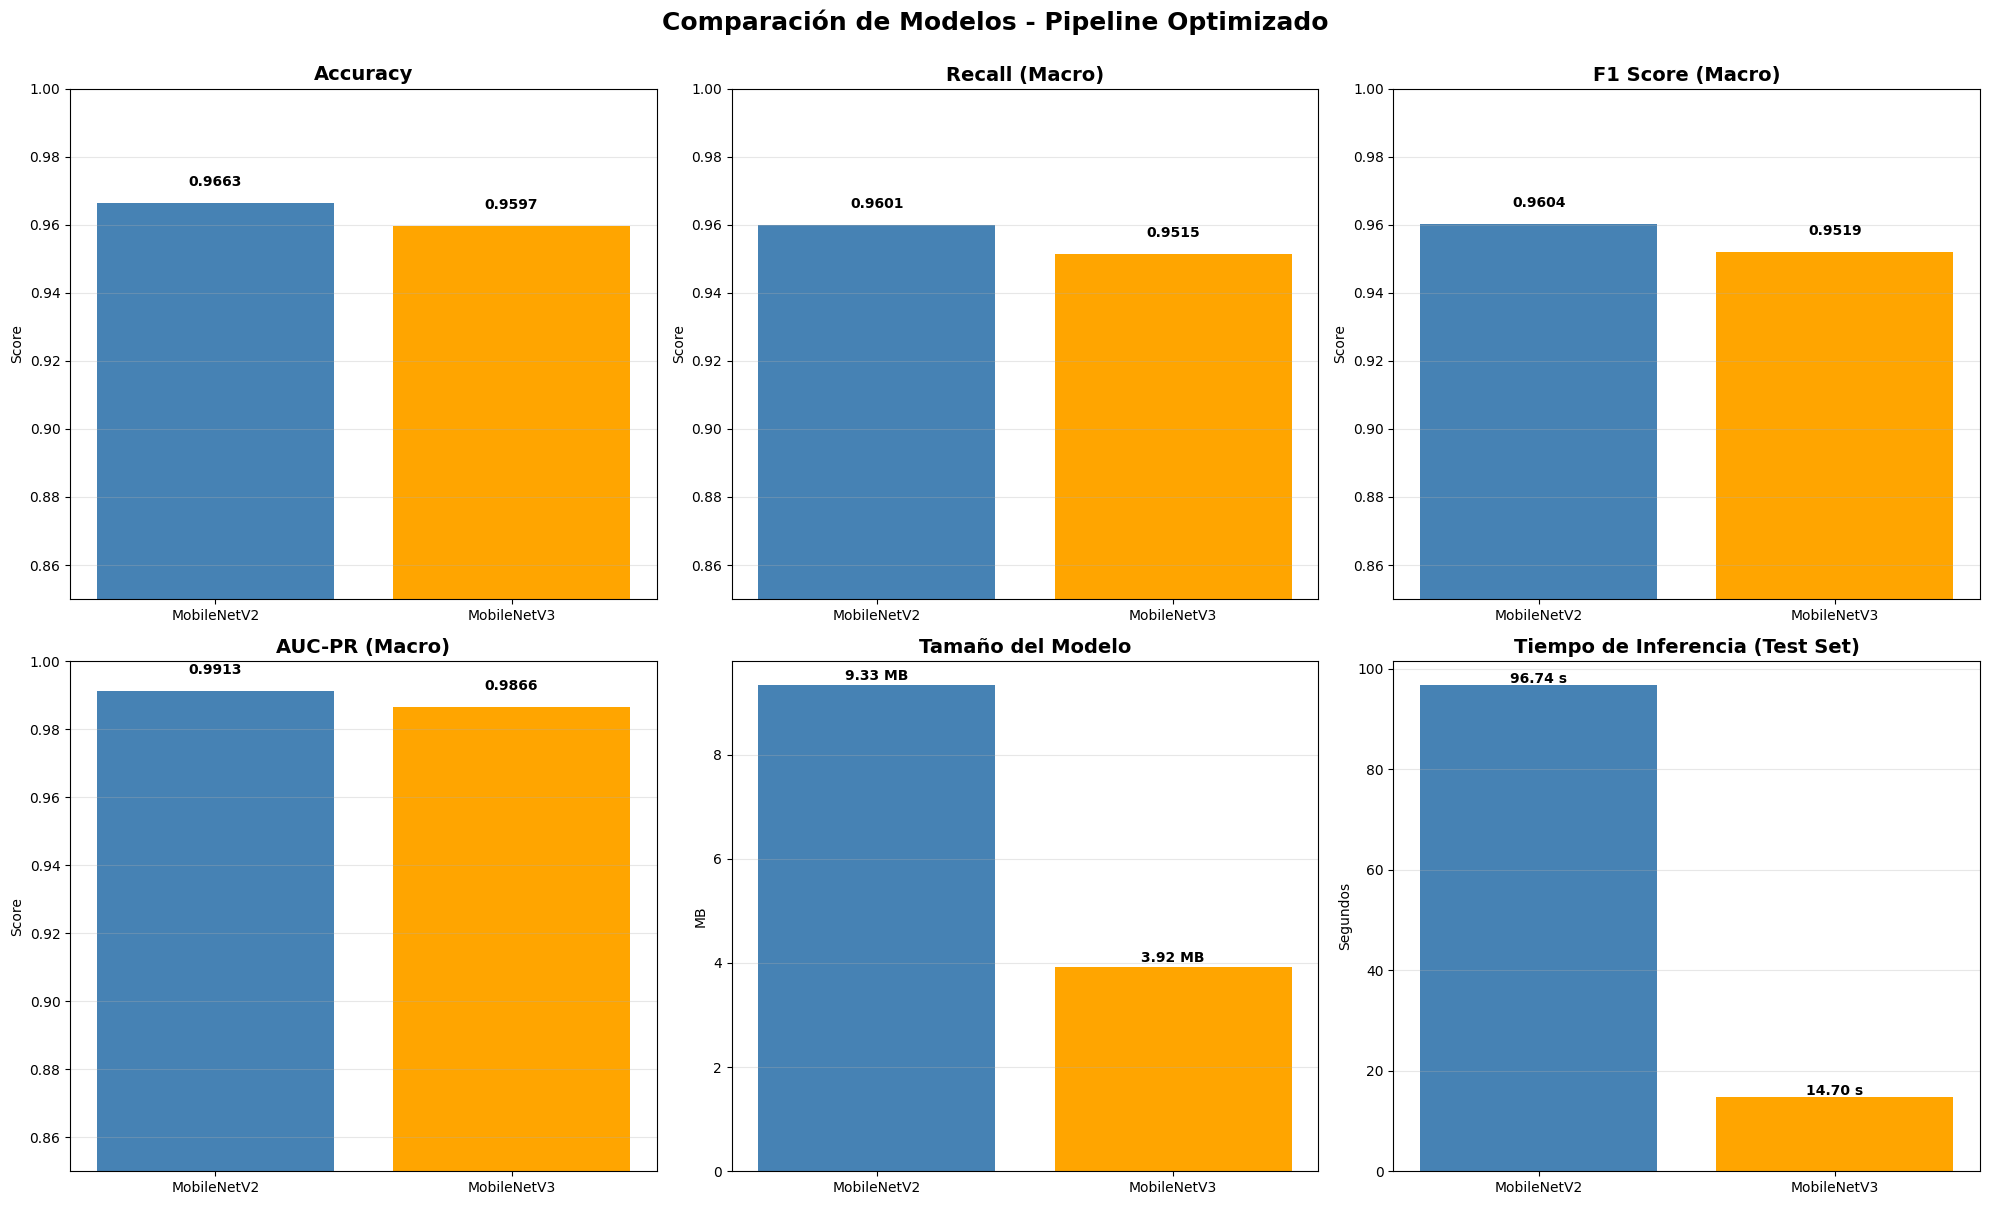

In [31]:
# Visualización comparativa
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

models_list = df_results.index.tolist()
colors = ['steelblue', 'orange', 'forestgreen']

# 1. Accuracy
axes[0, 0].bar(models_list, df_results['Accuracy'], color=colors)
axes[0, 0].set_title('Accuracy', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Score')
axes[0, 0].set_ylim(0.85, 1.0)
axes[0, 0].grid(axis='y', alpha=0.3)
for i, v in enumerate(df_results['Accuracy']):
    axes[0, 0].text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold')

# 2. Recall
axes[0, 1].bar(models_list, df_results['Recall'], color=colors)
axes[0, 1].set_title('Recall (Macro)', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Score')
axes[0, 1].set_ylim(0.85, 1.0)
axes[0, 1].grid(axis='y', alpha=0.3)
for i, v in enumerate(df_results['Recall']):
    axes[0, 1].text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold')

# 3. F1 Score
axes[0, 2].bar(models_list, df_results['F1 Score'], color=colors)
axes[0, 2].set_title('F1 Score (Macro)', fontsize=14, fontweight='bold')
axes[0, 2].set_ylabel('Score')
axes[0, 2].set_ylim(0.85, 1.0)
axes[0, 2].grid(axis='y', alpha=0.3)
for i, v in enumerate(df_results['F1 Score']):
    axes[0, 2].text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold')

# 4. AUC-PR
axes[1, 0].bar(models_list, df_results['AUC-PR'], color=colors)
axes[1, 0].set_title('AUC-PR (Macro)', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('Score')
axes[1, 0].set_ylim(0.85, 1.0)
axes[1, 0].grid(axis='y', alpha=0.3)
for i, v in enumerate(df_results['AUC-PR']):
    axes[1, 0].text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold')

# 5. Tamaño del modelo
axes[1, 1].bar(models_list, df_results['Size (MB)'], color=colors)
axes[1, 1].set_title('Tamaño del Modelo', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('MB')
axes[1, 1].grid(axis='y', alpha=0.3)
for i, v in enumerate(df_results['Size (MB)']):
    axes[1, 1].text(i, v + 0.1, f'{v:.2f} MB', ha='center', fontweight='bold')

# 6. Tiempo de inferencia
axes[1, 2].bar(models_list, df_results['Inference Time (s)'], color=colors)
axes[1, 2].set_title('Tiempo de Inferencia (Test Set)', fontsize=14, fontweight='bold')
axes[1, 2].set_ylabel('Segundos')
axes[1, 2].grid(axis='y', alpha=0.3)
for i, v in enumerate(df_results['Inference Time (s)']):
    axes[1, 2].text(i, v + 0.5, f'{v:.2f} s', ha='center', fontweight='bold')

plt.suptitle('Comparación de Modelos - Pipeline Optimizado',
             fontsize=18, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()


## 10. Resumen

Comparamos el impacto de nuestras optimizaciones:


In [24]:
print("="*70)
print("RESUMEN")
print("="*70)

print("\n1️⃣ ELIMINACIÓN DE DUPLICADOS")
print(f"   • Imágenes duplicadas eliminadas: {removed if duplicates else 0}")
print(f"   • Beneficio: Reduce overfitting y mejora generalización")

print("\n2️⃣ DATA AUGMENTATION SELECTIVO")
print(f"   • Imágenes sintéticas generadas: {generated_images}")
print(f"   • Clases balanceadas: {len(underrepresented_classes)}")
print(f"   • Beneficio: Mejora rendimiento en clases minoritarias")

print("\n3️⃣ OPTIMIZACIÓN DE HIPERPARÁMETROS (OPTUNA) V2")
print(f"   • Trials ejecutados: {10}")
print(f"   • Mejor AUC PR Score encontrado: {0.98564:.4f}")
print("   • Hiperparámetros optimizados:")
for key, value in best_params_v2.items():
    print(f"     - {key}: {value}")

print("\nOPTIMIZACIÓN DE HIPERPARÁMETROS (OPTUNA) V3")
print(f"   • Trials ejecutados: {10}")
print(f"   • Mejor AUC PR Score encontrado: {0.97122:.4f}")
print("   • Hiperparámetros optimizados:")
for key, value in best_params_v3.items():
    print(f"     - {key}: {value}")
print(f"   • Beneficio: Configuración óptima automática")

print("\n" + "="*70)


RESUMEN

1️⃣ ELIMINACIÓN DE DUPLICADOS
   • Imágenes duplicadas eliminadas: 21
   • Beneficio: Reduce overfitting y mejora generalización

2️⃣ DATA AUGMENTATION SELECTIVO
   • Imágenes sintéticas generadas: 8641
   • Clases balanceadas: 20
   • Beneficio: Mejora rendimiento en clases minoritarias

3️⃣ OPTIMIZACIÓN DE HIPERPARÁMETROS (OPTUNA) V2
   • Trials ejecutados: 10
   • Mejor AUC PR Score encontrado: 0.9856
   • Hiperparámetros optimizados:
     - lr: 0.0023345864076016252
     - batch_size: 32
     - hidden_dim: 1024
     - num_layers: 1
     - dropout: 0.12602063719411183
     - optimizer: Adam
     - weight_decay: 0.0002661901888489054

OPTIMIZACIÓN DE HIPERPARÁMETROS (OPTUNA) V3
   • Trials ejecutados: 10
   • Mejor AUC PR Score encontrado: 0.9712
   • Hiperparámetros optimizados:
     - lr: 0.0023345864076016252
     - batch_size: 32
     - hidden_dim: 1024
     - num_layers: 1
     - dropout: 0.12602063719411183
     - optimizer: Adam
     - weight_decay: 0.0002661901888489

## 11. Guardar Modelos y Configuración

Guardamos los modelos entrenados y la configuración para uso posterior.


In [ ]:
# Guardar modelos
torch.save(model_v2_opt.state_dict(), 'mobilenetv2_optimized.pth')
torch.save(model_v3_opt.state_dict(), 'mobilenetv3_small.pth')

# Guardar hiperparámetros óptimos
import json

config = {
    'best_hyperparameters_v2': best_params_v2,
    'best_hyperparameters_v3': best_params_v3,
    'num_classes': num_classes,
    'class_names': full_dataset.classes,
    'results': results
}

with open('model_config.json', 'w') as f:
    json.dump(config, f, indent=2, default=str)

print("✅ Modelos y configuración guardados:")
print("   - mobilenetv2_optimized.pth")
print("   - mobilenetv3_small.pth")
print("   - model_config.json")

# Guardar resultados en CSV
df_results.to_csv('model_comparison_results.csv')
print("   - model_comparison_results.csv")
